# Modular PDE-Constrained Optimization with Neural Networks

This notebook provides a unified interface to run all examples from the paper using the modular components.

## Running Options

### Option 1: Local GPU (WSL/Linux with NVIDIA GPU)

### Option 2: Google Colab GPU (for team members without local GPU)
See instructions in cell below

In [11]:
# GPU Setup Check
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Mount Google Drive for persistent storage
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Install required packages
    !pip install -q jax[cuda12] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
    !pip install -q flax optax matplotlib
    !nvidia-smi
else:
    print("Running locally")
    # Optional: Check if running in virtual environment
    import os
    if hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix):
        print(f"✓ Virtual environment active: {sys.prefix}")
    else:
        print("⚠ Not in virtual environment. Activate with: source venv/bin/activate")
    
# Check JAX and GPU
import jax
print(f"\nJAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")

if jax.default_backend() == 'gpu':
    print("✓ GPU acceleration enabled!")
    # Try to get GPU info
    try:
        import subprocess
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], 
                              capture_output=True, text=True)
        if result.returncode == 0:
            print(f"GPU: {result.stdout.strip()}")
    except:
        pass
else:
    print("⚠ Running on CPU")

Running locally
✓ Virtual environment active: /home/mark/pde-constrained-opt-nn/venv

JAX version: 0.7.2
Available devices: [CudaDevice(id=0)]
Backend: gpu
✓ GPU acceleration enabled!
GPU: NVIDIA GeForce RTX 4060, 8188 MiB


## Setup and Imports

In [12]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from typing import Dict, Any, Tuple, Optional
import time

# If modules don't exist yet, we'll define them inline
try:
    from solvers import get_solver, HeatEquationFD, HeatEquationFEM, HeatEquationCrankNicolson
    from problems import get_problem
    from examples import get_example, create_neural_network
    print("Modules loaded successfully")
except ImportError:
    print("Warning: Modules not found. Copy the module files to Colab or define inline.")
    # You can paste the module code here if needed

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

Modules loaded successfully


## Module Definitions (if not imported)

If the modules aren't available, uncomment and run the cells below:

In [13]:
# Optional: Define create_neural_network function if modules not available
def create_neural_network(hidden_layers: list = [256, 256], activation: str = 'tanh'):
    """Create a neural network for force/parameter approximation."""
    
    class Network(nn.Module):
        layers: list
        activation: str
        
        @nn.compact
        def __call__(self, x):
            for i, features in enumerate(self.layers):
                x = nn.Dense(features)(x)
                if i < len(self.layers) - 1:
                    if self.activation == 'tanh':
                        x = nn.tanh(x)
                    elif self.activation == 'relu':
                        x = nn.relu(x)
            x = nn.Dense(1)(x)  # Output layer
            return x.squeeze(-1)
    
    return Network(layers=hidden_layers, activation=activation)

## Configuration: Select Problem and Solver

In [14]:
# Configuration - modify these to run different examples
CONFIG = {
    'example': '3.3',  # Options: '3.1', '3.2', '3.3'
    'max_iterations': 3500,  # Match working notebook
    'zero_ic': True,  # For heat equation examples
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  example: 3.3
  max_iterations: 3500
  zero_ic: True


## Initialize Problem and Solver

In [15]:
# Simply get the example and run it!
print(f"\nRunning Example {CONFIG['example']}...")
print("="*60)

ex = get_example(f"example-{CONFIG['example']}", zero_ic=CONFIG.get('zero_ic', True))

# Run the example
if CONFIG['example'] == '3.1':
    result, losses = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal force estimate: {result:.6f} (true: -1.0)")
elif CONFIG['example'] == '3.2':
    result, losses = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
elif CONFIG['example'] == '3.3':
    params, losses, force, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
    
    # Store results for plotting
    import jax
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"NN parameters: {n_params}")
    
    # Reshape for plotting
    nx, nt = ex.grid_params['nx'], ex.grid_params['nt']
    force_2d = force.reshape(nx, nt)
    solution_2d = solution.reshape(nx, nt)

print("="*60)


Running Example 3.3...
Using TIME-STEPPING solver (matches working notebook)
ep    0 | L=0.254087 | mis=0.254087 | regF=0.000000
ep   50 | L=0.018922 | mis=0.018563 | regF=0.000359
ep  100 | L=0.011008 | mis=0.010697 | regF=0.000311
ep  150 | L=0.002204 | mis=0.001876 | regF=0.000327
ep  200 | L=0.001174 | mis=0.000845 | regF=0.000329
ep  250 | L=0.001089 | mis=0.000763 | regF=0.000326
ep  300 | L=0.001011 | mis=0.000689 | regF=0.000323
ep  350 | L=0.000943 | mis=0.000623 | regF=0.000320
ep  400 | L=0.000885 | mis=0.000568 | regF=0.000317
ep  450 | L=0.000804 | mis=0.000495 | regF=0.000310
ep  500 | L=0.000744 | mis=0.000436 | regF=0.000307
ep  550 | L=0.000690 | mis=0.000386 | regF=0.000304
ep  600 | L=0.000666 | mis=0.000362 | regF=0.000304
ep  650 | L=0.000602 | mis=0.000304 | regF=0.000298
ep  700 | L=0.000624 | mis=0.000325 | regF=0.000299
ep  750 | L=0.000521 | mis=0.000228 | regF=0.000292
ep  800 | L=0.000567 | mis=0.000283 | regF=0.000283
ep  850 | L=0.000448 | mis=0.000163 | 

## Setup Target Solution and System Matrix

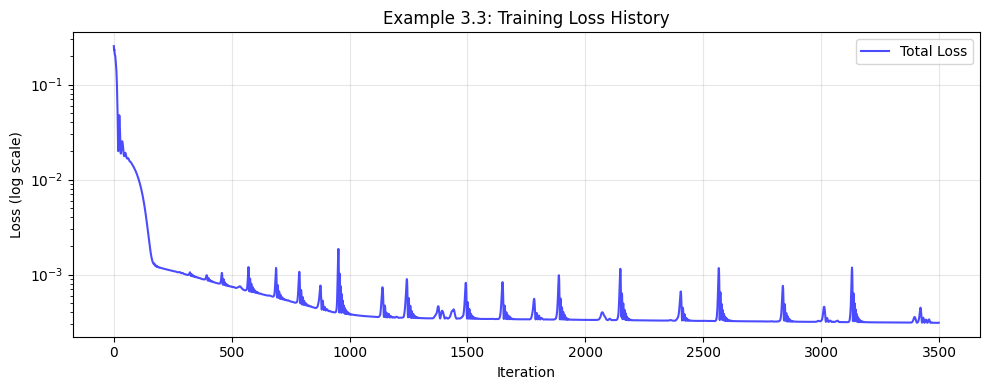


Loss decreased from 2.540869e-01 to 3.108642e-04


In [16]:
# Plot loss history
if CONFIG['example'] in ['3.2', '3.3']:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 4))
    plt.semilogy(losses, 'b-', alpha=0.7, label='Total Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (log scale)')
    plt.title(f"Example {CONFIG['example']}: Training Loss History")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nLoss decreased from {losses[0]:.6e} to {losses[-1]:.6e}")

## Visualization: Solutions

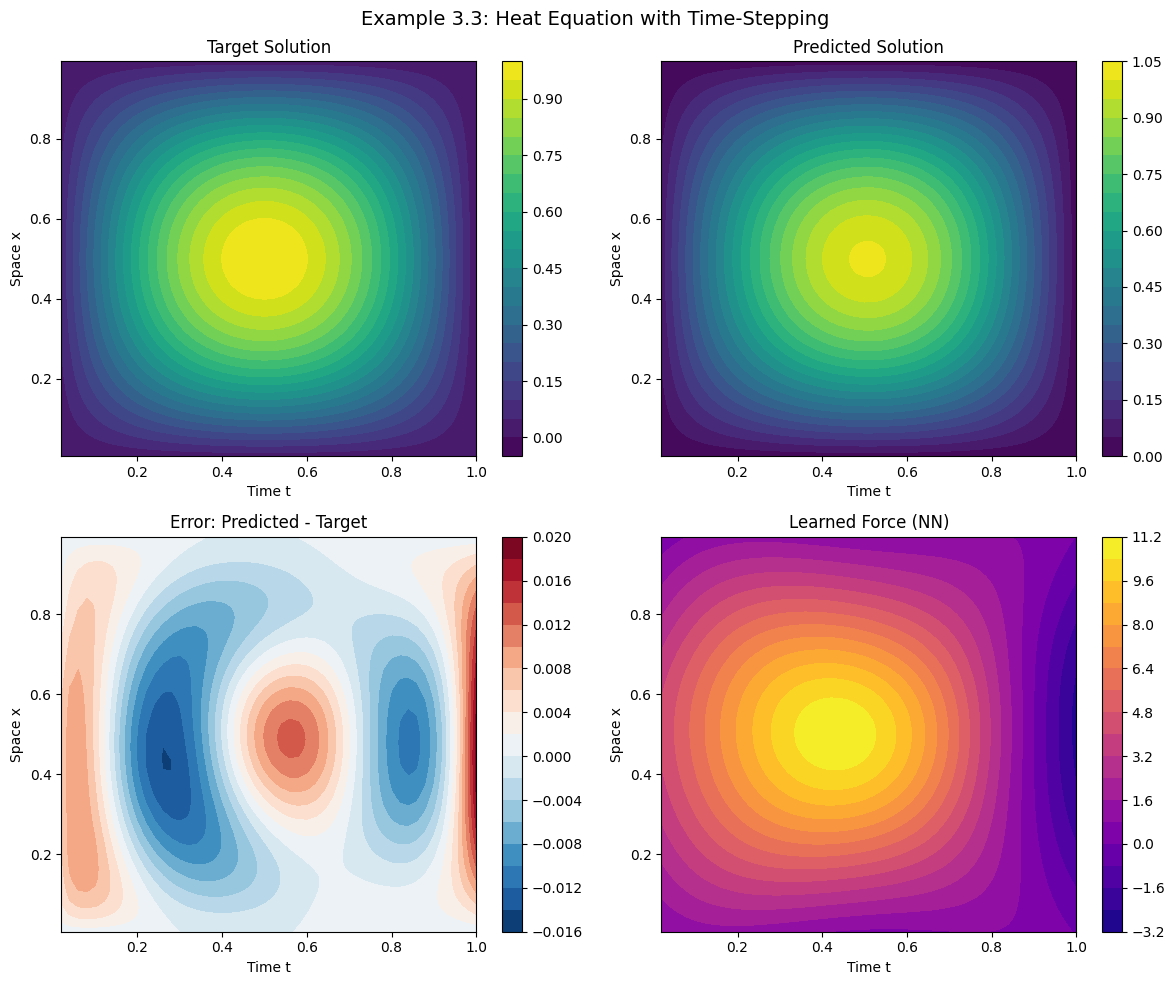


Error Metrics:
  MSE:              3.729105e-05
  Relative L2:      1.217250e-02 (1.22%)


In [17]:
# Visualize results for heat equation (Example 3.3)
if CONFIG['example'] == '3.3':
    import matplotlib.pyplot as plt
    from problems import get_problem
    from solvers import get_solver
    
    # Get grid
    solver = get_solver('heat', 'fd', nx=ex.grid_params['nx'], nt=ex.grid_params['nt'])
    x_grid = solver.x_grid
    t_grid = solver.t_grid
    
    # Get true solution
    problem = get_problem('heat-1d', zero_ic=CONFIG['zero_ic'])
    u_target = problem.analytical_solution(x_grid, t_grid)
    
    # Create meshgrid
    X, T = jnp.meshgrid(x_grid, t_grid, indexing='ij')
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Target solution
    im1 = axes[0,0].contourf(T, X, u_target, levels=20, cmap='viridis')
    axes[0,0].set_xlabel('Time t')
    axes[0,0].set_ylabel('Space x')
    axes[0,0].set_title('Target Solution')
    plt.colorbar(im1, ax=axes[0,0])
    
    # Predicted solution
    im2 = axes[0,1].contourf(T, X, solution_2d, levels=20, cmap='viridis')
    axes[0,1].set_xlabel('Time t')
    axes[0,1].set_ylabel('Space x')
    axes[0,1].set_title('Predicted Solution')
    plt.colorbar(im2, ax=axes[0,1])
    
    # Error
    error_2d = solution_2d - u_target
    im3 = axes[1,0].contourf(T, X, error_2d, levels=20, cmap='RdBu_r')
    axes[1,0].set_xlabel('Time t')
    axes[1,0].set_ylabel('Space x')
    axes[1,0].set_title('Error: Predicted - Target')
    plt.colorbar(im3, ax=axes[1,0])
    
    # Learned force
    im4 = axes[1,1].contourf(T, X, force_2d, levels=20, cmap='plasma')
    axes[1,1].set_xlabel('Time t')
    axes[1,1].set_ylabel('Space x')
    axes[1,1].set_title('Learned Force (NN)')
    plt.colorbar(im4, ax=axes[1,1])
    
    plt.suptitle(f"Example {CONFIG['example']}: Heat Equation with Time-Stepping", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Error metrics
    mse = jnp.mean((solution_2d - u_target)**2)
    rel_err = jnp.linalg.norm(solution_2d.flatten() - u_target.flatten()) / jnp.linalg.norm(u_target.flatten())
    print(f"\nError Metrics:")
    print(f"  MSE:              {mse:.6e}")
    print(f"  Relative L2:      {rel_err:.6e} ({100*rel_err:.2f}%)")
else:
    print("Visualization only available for Example 3.3")